# Unsupervised Learning - Exercise

```In this exercise you will experience with K-Means, and PCA, and will do some use of them for handling practical problems.```

~```Gilad Royz & Itai Haran```

# Part 1 - Clustering

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

Dataset shape: (600, 2)

Clustering Performance Comparison:
K-means Silhouette Score: 0.398
GMM Silhouette Score: 0.346


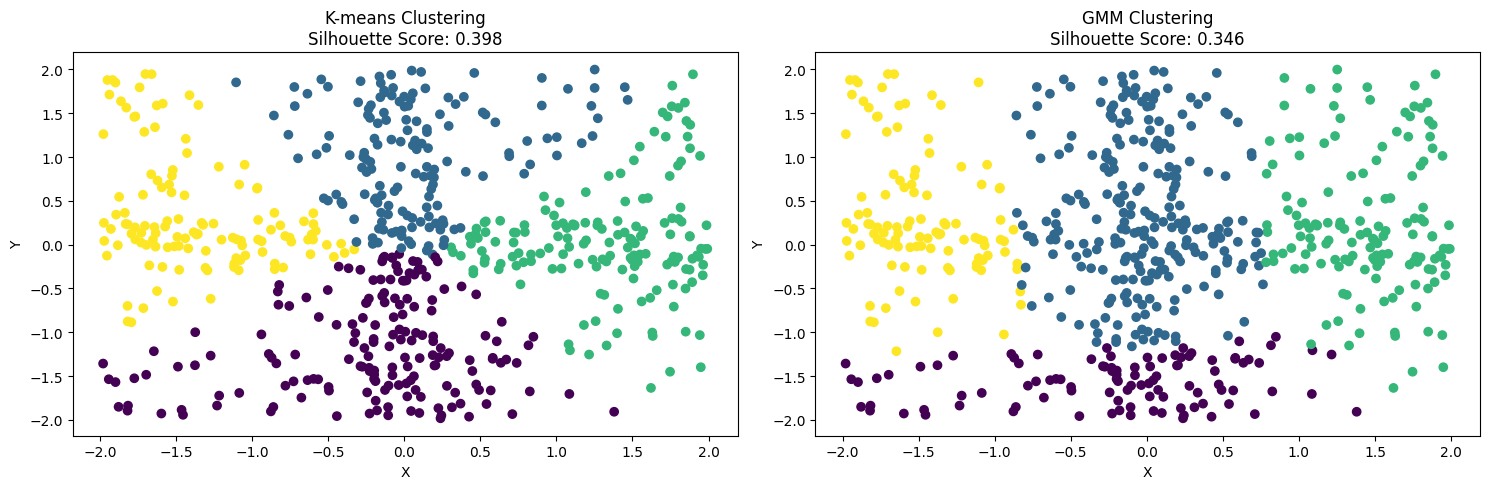

In [9]:


# Set random seed for reproducibility
np.random.seed(42)

def generate_challenging_data():
    # Generate uniform square clusters
    n_samples = 300
    
    # Create a square-shaped cluster
    square1 = np.random.uniform(low=[-2, -2], high=[2, 2], size=(n_samples, 2))
    
    # Create a cross-shaped pattern inside the square
    cross_x = np.random.uniform(low=-0.3, high=0.3, size=(n_samples//2, 1))
    cross_y = np.random.uniform(low=-2, high=2, size=(n_samples//2, 1))
    cross_horizontal = np.hstack([cross_x, cross_y])
    
    cross_y = np.random.uniform(low=-0.3, high=0.3, size=(n_samples//2, 1))
    cross_x = np.random.uniform(low=-2, high=2, size=(n_samples//2, 1))
    cross_vertical = np.hstack([cross_x, cross_y])
    
    # Combine the datasets
    cross = np.vstack([cross_horizontal, cross_vertical])
    
    # Create the final dataset
    X = np.vstack([square1, cross])
    
    return X

def plot_clustering_comparison(X, n_clusters=4):
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # K-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(X)
    
    # GMM clustering
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    gmm_labels = gmm.fit_predict(X)
    
    # Calculate silhouette scores
    kmeans_silhouette = silhouette_score(X, kmeans_labels)
    gmm_silhouette = silhouette_score(X, gmm_labels)
    
    # Plot K-means results
    ax1.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
    ax1.set_title(f'K-means Clustering\nSilhouette Score: {kmeans_silhouette:.3f}')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    
    # Plot GMM results
    ax2.scatter(X[:, 0], X[:, 1], c=gmm_labels, cmap='viridis')
    ax2.set_title(f'GMM Clustering\nSilhouette Score: {gmm_silhouette:.3f}')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    
    plt.tight_layout()
    return kmeans_silhouette, gmm_silhouette

# Generate and visualize the data
X = generate_challenging_data()
kmeans_score, gmm_score = plot_clustering_comparison(X)

print(f"Dataset shape: {X.shape}")
print(f"\nClustering Performance Comparison:")
print(f"K-means Silhouette Score: {kmeans_score:.3f}")
print(f"GMM Silhouette Score: {gmm_score:.3f}")

```In this question you are asked to examine the 3 clustering algorithms: KMeans, DBscan and GaussianMixture.```

```You will have to generate manipulative datasets, and demonstrate the weaknesses of each method. That is, for each one of the clustering methods, generate a dataset such that one of the methods will fail, and the others will not.
Deal with the model's hyper parameters, and conclude for yourself how sensitive they are.```

```For each dataset draw your results using your favorite visualization tool.```

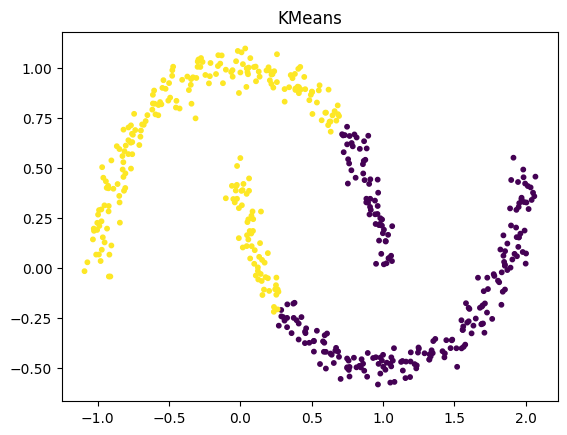

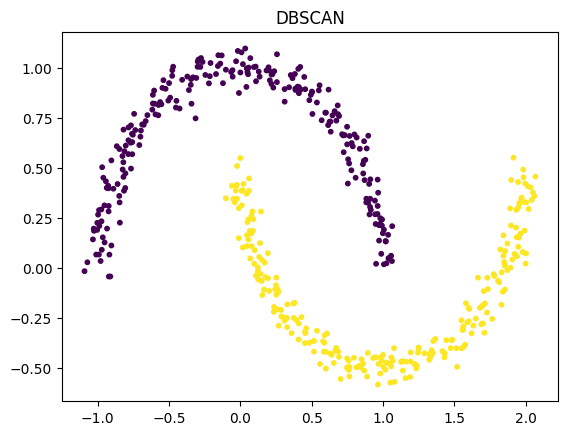

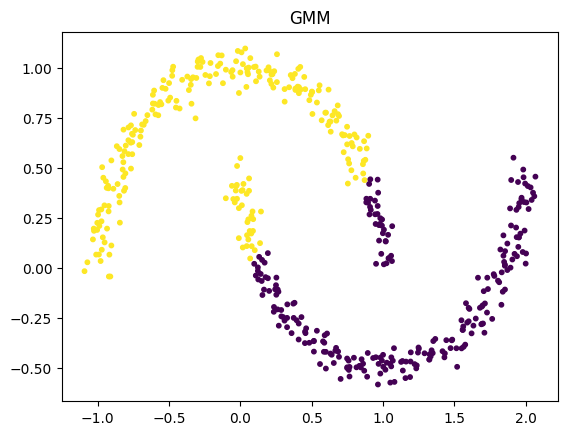

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

def plot_clusters(X, labels, title):
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=10)
    plt.title(title)
    plt.show()

# Dataset where KMeans fails (non-convex shapes)
X_moons, _ = make_moons(n_samples=500, noise=0.05)

kmeans = KMeans(n_clusters=2)
labels_kmeans = kmeans.fit_predict(X_moons)
plot_clusters(X_moons, labels_kmeans, "KMeans")

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_moons)
plot_clusters(X_moons, labels_dbscan, "DBSCAN")

gmm = GaussianMixture(n_components=2)
labels_gmm = gmm.fit_predict(X_moons)
plot_clusters(X_moons, labels_gmm, "GMM")



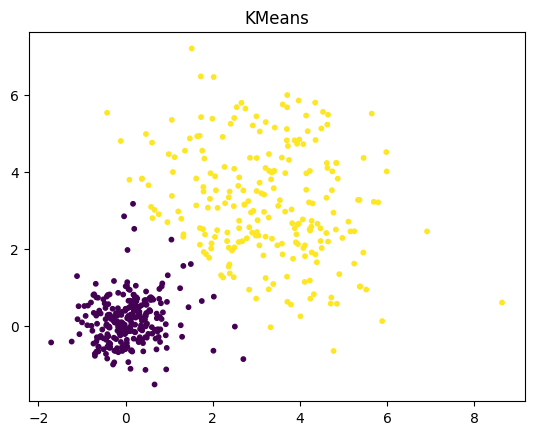

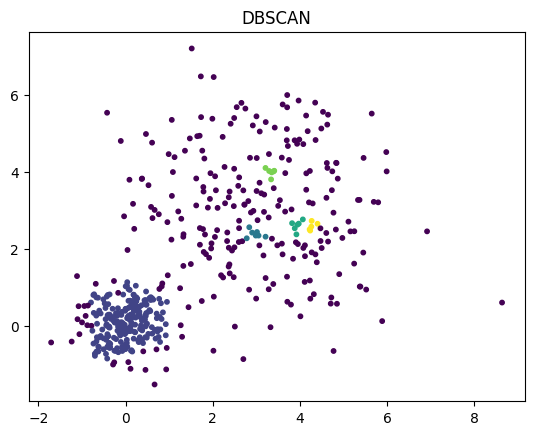

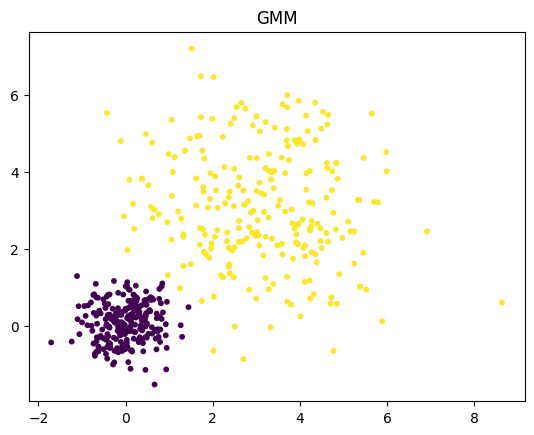

In [6]:
# Dataset where DBSCAN fails (clusters with varying density)
X_blobs, _ = make_blobs(n_samples=500, centers=[[0, 0], [3, 3]], cluster_std=[0.5, 1.5])

labels_kmeans = kmeans.fit_predict(X_blobs)
plot_clusters(X_blobs, labels_kmeans, "KMeans")

labels_dbscan = dbscan.fit_predict(X_blobs)
plot_clusters(X_blobs, labels_dbscan, "DBSCAN")

labels_gmm = gmm.fit_predict(X_blobs)
plot_clusters(X_blobs, labels_gmm, "GMM")

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

### your code here

```Answer the following questions based on what you learned from the previous question:```
- ```Which method is easiest to use?```
- ```Which method is the fastest to use?```

```We will now use K-Means to quantize image colors:```

    ```First load the given celebrity image from the image folder (can be found in:```
    https://drive.google.com/file/d/1nUk_Q-ahhUrjmUl_sM9ovb84DybuaQCe/view?usp=sharing)

In [16]:
import cv2
img = cv2.imread('c:/Users/user/Desktop/DStrainig/intro/unsupervised/images/Alicia Vikander/1.jpg')[:,:,::-1]
img_array = np.array(img)

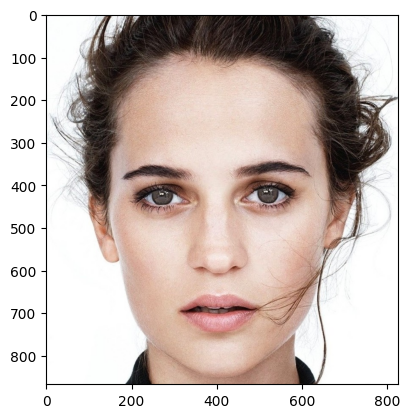

In [4]:
plt.imshow(img_array)

```Every pixel in the image is composed of three colors (Red, Green, Blue), and therefore, every pixel is a vector: (r,g,b).```
```Create a list of every color pixel in the image: (array.reshape will work)```

In [5]:
pixels = img.reshape(-1, 3)

print(pixels[200:205])

[[ 96  82  71]
 [ 84  70  59]
 [ 54  40  31]
 [ 77  64  55]
 [127 114 106]]


```Train a K-Means model with k=10 on the list of colors:```

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10)

clusters = kmeans.fit_predict(pixels)

new_dataset = kmeans.cluster_centers_[clusters]




```Now replace every color vector with the vector of centroid bector of it's cluster.```
```rebuild the image and plot it. How is it compared to the original?```

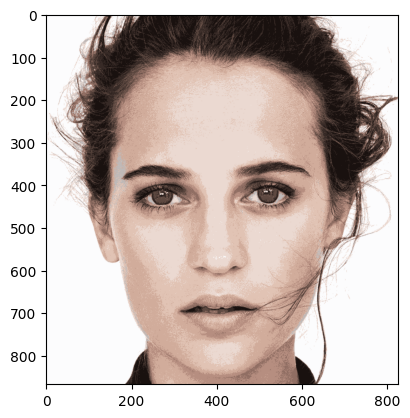

In [7]:
plt.imshow(new_dataset.reshape(img_array.shape).astype(np.uint8))

```Train K-Means model with k=2,...,15, and plot the "within-cluster sum-of-squares criterion"```($R_k$)``` for all the k's.```

```(reduce the n_init if it takes too much time)```

(Explain on $R_k$ can be found in: https://scikit-learn.org/stable/modules/clustering.html#k-means)

```Can we conclude "how many clusters" are there, from the graph?```

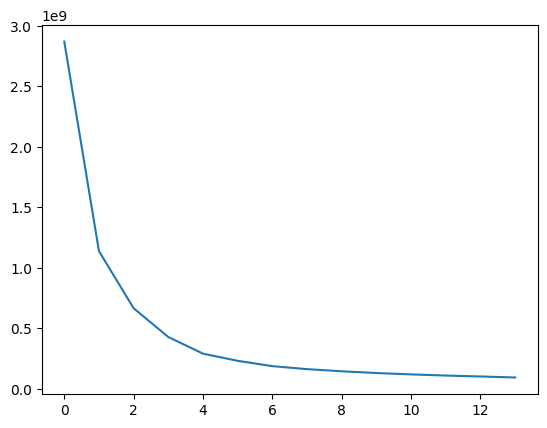

In [8]:
errors = []
for i in range(2, 16):
    kmeans = KMeans(i)
    kmeans.fit(pixels)
    errors += [kmeans.inertia_]
plt.plot(errors)

# part 2 - Dimensionality reduction

```The goal of this part is to experience with some basic features of PCA, and have a notion about the capabilities, and uses of this method.```

```We will look on facial images of 3 celebrities, and use PCA to extract facial patterns from images.```
```We then try to use those patterns to build a classifier that can distinguish the 3 celebrities.```

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import cv2
from sklearn.model_selection import train_test_split


In [9]:
celebs = ['Alicia Vikander', 'Amy Adams', 'Andy Serkis']


In [10]:
def read_gray_image(path):

    return cv2.cvtColor(cv2.imread(path)[:,:,::-1], cv2.COLOR_RGB2GRAY)

```First we load the face images:```

In [17]:
import os

face_imgs = []
labels = []
for j, c in enumerate(celebs):
    
    dir_path = 'c:/Users/user/Desktop/DStrainig/intro/unsupervised/images/{}/'.format(c)
    dir_file_paths = [dir_path + i for i in os.listdir(dir_path)]
    
    temp_imgs = [read_gray_image(dir_path + i) for i in os.listdir(dir_path)]
    
    labels += [j]*len(dir_file_paths)
    face_imgs += [read_gray_image(i) for i in dir_file_paths]

```For later steps, we would like to resize all the images to have the same width x height. It is best to choose new shape that least distort the images.```

```Plot the shapes of all the images on the "width", "height" plane: (What does that remind you of?)```

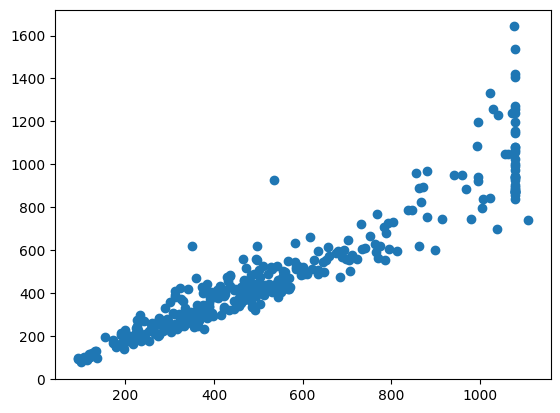

In [21]:
all_shapes = np.array([i.shape for i in face_imgs])
plt.scatter(all_shapes[:,0], all_shapes[:,1])

```Now on the same plot, draw the point of the "avarage shape". Is it looks like it represents the trend?```

```Resize all the face images to have the "avarage shape." ( cv2.resize will work)```

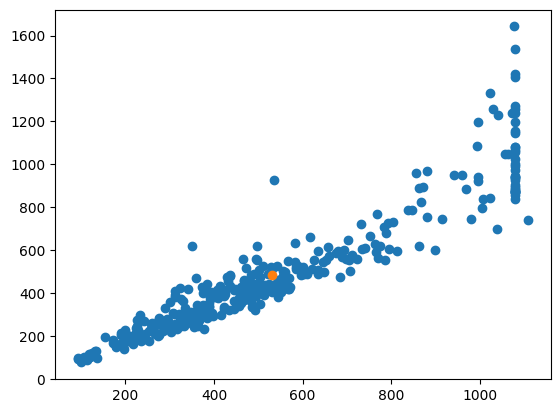

In [22]:
plt.scatter(all_shapes[:,0], all_shapes[:,1])
plt.scatter([all_shapes[:,0].mean()], [all_shapes[:,1].mean()])

In [23]:
print(([all_shapes[:,0].mean()], [all_shapes[:,1].mean()]))

([np.float64(530.6918767507003)], [np.float64(485.2044817927171)])


In [24]:
resized_imgs = [cv2.resize(img, (530,485)) for img in face_imgs]


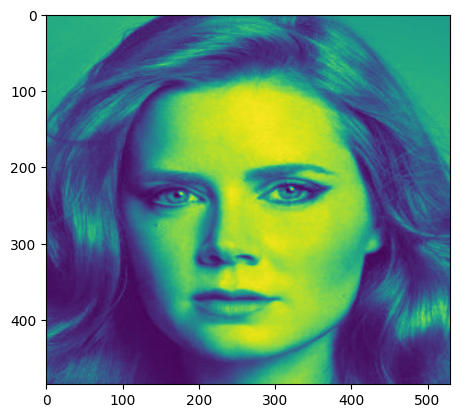

In [55]:
plt.imshow(resized_imgs[np.where(np.array(labels)==1)[0][0]])
plt.show()

```Flatten all the images into vectors, and split them randomly to train and test groups (with ratio (0.7, 0.3)).```

In [67]:
flattened_imgs = np.array([img.flatten() for img in resized_imgs])

X_train, X_test, Y_train, Y_test = train_test_split(flattened_imgs, labels, test_size=0.3, random_state=42)


```Now train a PCA model with n_components=10 on the train set. How much variance(in %) the 10 components explain? is it good compared to the dimention of the vectors?```

In [68]:
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
print(np.sum(pca.explained_variance_ratio_) * 100)


74.11673046729821


```Take the 10 component vectors of the model, reshape them to the image shape, and plot all of them:```

It looks something like that:
![image.png](attachment:image.png)

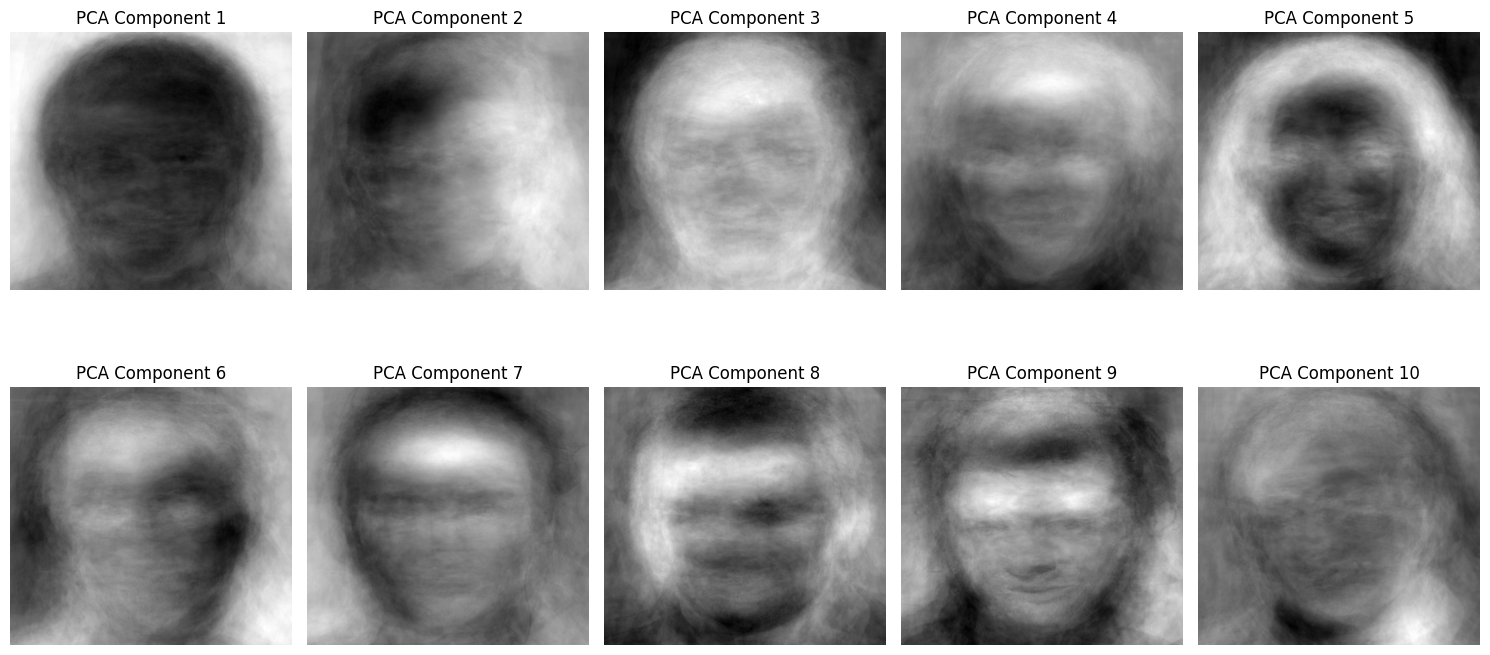

In [69]:
components = pca.components_
original_shape = resized_imgs[0].shape

plt.figure(figsize=(15, 8))

for i in range(10):
    component_img = components[i].reshape(original_shape)
    
    plt.subplot(2, 5, i + 1)
    # נרמול הערכים לטווח [1,0-] לתצוגה טובה יותר
    plt.imshow(component_img, cmap='gray')
    plt.title(f'PCA Component {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()


```The "faces" that we got, can roוghly be refered to as the "face patterns" that are the most dominant in the images. can you make sense of the patterns?```

```Notice that if we transform an image to the low dimension and then inverse transform it back, we actually find the "best combination of the patterns" that reconstract out image```

```Now make a PCA model with n_components=10 for the images of every celebrity in the train set (pca_1, pca_2, pca_3). And Then:```

- ```Take all the vectors from the test set.```
- ```Transform them to the low dimension.```
- ```Inverse transform them back to original dimension.```
- ```Compute "mean square error" (MSE) between the original vectors to the reconstructed version of themselves.```
- ```For every vector, mark the PCA model that gave the smallest MSE. (as prediction)```
- ```Print the "confusion matrix" of the prediction.``` (https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html)

In [72]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix

pcas = []
for i in range(3):
    pca = PCA(20)
    pca.fit(X_train[np.array(Y_train)==i])
    pcas += [pca]

In [73]:
recovered = []
for i in range(3):
    recovered += [pcas[i].inverse_transform(pcas[i].transform(X_test))]
recovered = np.array(recovered)
recovering_errors = np.linalg.norm(recovered - X_test, axis=2)
best_recovring_celeb = np.argmin(recovering_errors, axis=0)
mat = confusion_matrix(Y_test, best_recovring_celeb)
accuracy = np.mean(Y_test == best_recovring_celeb)
print('accuracy: ', accuracy)
print('confusion matrix:\n', mat)

accuracy:  0.8703703703703703
confusion matrix:
 [[31  3  3]
 [ 3 28  2]
 [ 1  2 35]]


```Is it work well? If yes, try to explain why.```

In [ ]:
#כל PCA מזהה את התבנית של הסלב הספציפי

## Bonus (5 pts)

```Perform the prediction process with PCA models with n_components=[1,10,20,30,40,50,60,70].```


Results for n_components = 1:
Accuracy: 0.741
Confusion Matrix:
[[24  3 10]
 [ 5 23  5]
 [ 3  2 33]]

Results for n_components = 10:
Accuracy: 0.759
Confusion Matrix:
[[29  6  2]
 [ 8 25  0]
 [ 4  6 28]]

Results for n_components = 20:
Accuracy: 0.852
Confusion Matrix:
[[30  4  3]
 [ 3 28  2]
 [ 1  3 34]]

Results for n_components = 30:
Accuracy: 0.861
Confusion Matrix:
[[30  5  2]
 [ 3 27  3]
 [ 0  2 36]]

Results for n_components = 40:
Accuracy: 0.861
Confusion Matrix:
[[29  5  3]
 [ 2 28  3]
 [ 0  2 36]]

Results for n_components = 50:
Accuracy: 0.843
Confusion Matrix:
[[29  5  3]
 [ 4 26  3]
 [ 0  2 36]]

Results for n_components = 60:
Accuracy: 0.843
Confusion Matrix:
[[30  5  2]
 [ 4 26  3]
 [ 0  3 35]]

Results for n_components = 70:
Accuracy: 0.824
Confusion Matrix:
[[29  7  1]
 [ 4 26  3]
 [ 0  4 34]]


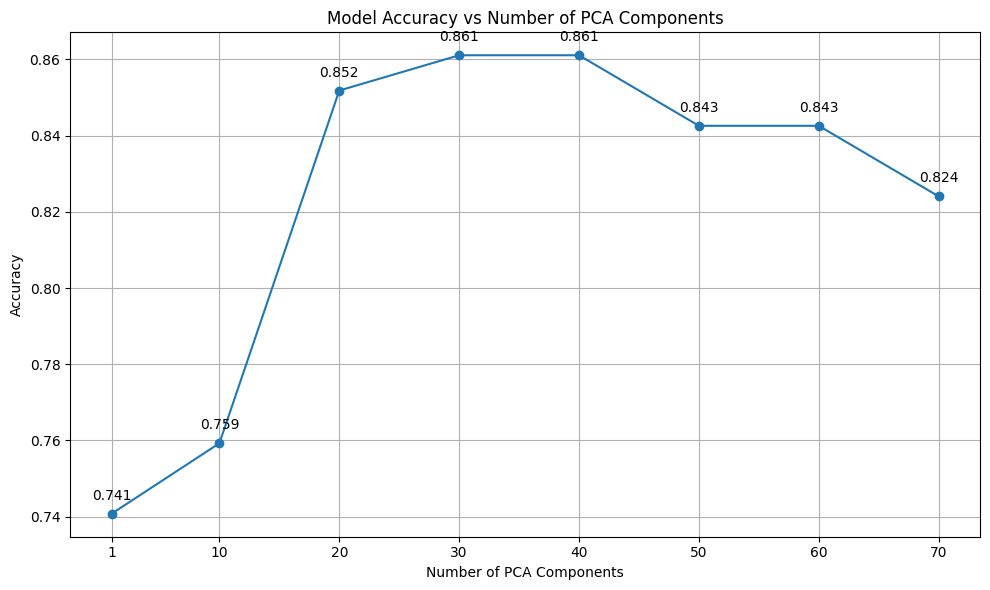


Summary:
Minimum accuracy: 0.7407407407407407 with 1 components
Maximum accuracy: 0.8611111111111112 with 30 components


In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

# הגדרת מספרי הרכיבים שנרצה לבדוק
n_components_list = [1, 10, 20, 30, 40, 50, 60, 70]
accuracies = []

# ריצה על כל מספר רכיבים
for n_comp in n_components_list:
    # אתחול רשימת מודלי PCA לכל קלאס
    pcas = []
    
    # אימון PCA נפרד לכל קלאס
    for i in range(3):
        pca = PCA(n_components=n_comp)
        pca.fit(X_train[np.array(Y_train)==i])
        pcas.append(pca)
    
    # חישוב השחזור עבור כל קלאס
    recovered = []
    for i in range(3):
        recovered.append(pcas[i].inverse_transform(pcas[i].transform(X_test)))
    recovered = np.array(recovered)
    
    # חישוב שגיאות השחזור
    recovering_errors = np.linalg.norm(recovered - X_test, axis=2)
    
    # חיזוי הקלאס על פי השגיאה המינימלית
    best_recovering_celeb = np.argmin(recovering_errors, axis=0)
    
    # חישוב דיוק והוספה לרשימת התוצאות
    accuracy = np.mean(Y_test == best_recovering_celeb)
    accuracies.append(accuracy)
    
    # הדפסת תוצאות ביניים
    print(f'\nResults for n_components = {n_comp}:')
    print(f'Accuracy: {accuracy:.3f}')
    print('Confusion Matrix:')
    print(confusion_matrix(Y_test, best_recovering_celeb))

# יצירת גרף המציג את הדיוק כפונקציה של מספר הרכיבים
plt.figure(figsize=(10, 6))
plt.plot(n_components_list, accuracies, marker='o')
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.title('Model Accuracy vs Number of PCA Components')
plt.grid(True)
plt.xticks(n_components_list)

# הוספת ערכי הדיוק מעל הנקודות
for i, acc in enumerate(accuracies):
    plt.annotate(f'{acc:.3f}', 
                (n_components_list[i], acc),
                textcoords="offset points", 
                xytext=(0,10), 
                ha='center')

plt.tight_layout()
plt.show()

# הדפסת סיכום
print("\nSummary:")
print("Minimum accuracy:", min(accuracies), "with", n_components_list[np.argmin(accuracies)], "components")
print("Maximum accuracy:", max(accuracies), "with", n_components_list[np.argmax(accuracies)], "components")

```Plot the accuracy of the models. what is the trend of the performance when n_components increases? Is it what you expected? try to explain.```

In [ ]:
# low PCA lead to underfitting, high PCA lead to overfitting....